# 🚀 SpaceX Falcon 9 Landing Prediction
## Notebook 4 — EDA with Visualization

We dig into the dataset visually to uncover patterns before modelling.

**Key questions:**
- Which launch sites have the best success rates?
- How does payload mass relate to landing success?
- How has success rate improved over time (flight number)?
- Which orbit types are linked to successful landings?


In [1]:
%pip install matplotlib seaborn pandas numpy -q
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
# IBM Part-2 dataset — includes feature-engineered columns
df = pd.read_csv(
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud"
    "/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
)
print(f"Shape: {df.shape}")
df.head()


Shape: (90, 18)


,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


### 1 — Flight Number vs Launch Site (coloured by outcome)

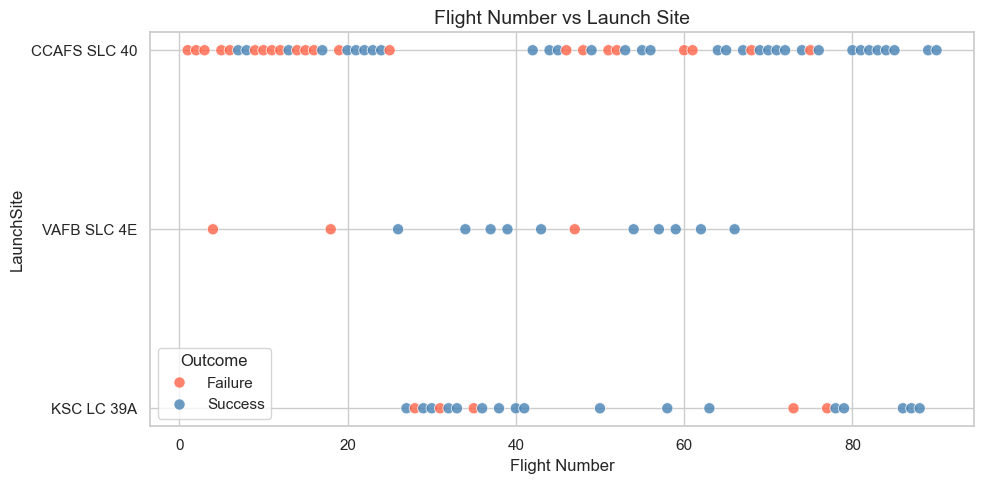

In [3]:
fig, ax = plt.subplots()
sns.scatterplot(
    data=df, x='FlightNumber', y='LaunchSite',
    hue='Class', palette={0: 'tomato', 1: 'steelblue'},
    s=65, alpha=0.8, ax=ax
)
ax.set_title("Flight Number vs Launch Site")
ax.set_xlabel("Flight Number")
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ['Failure', 'Success'], title="Outcome")
plt.tight_layout()
plt.show()


### 2 — Payload Mass vs Launch Site

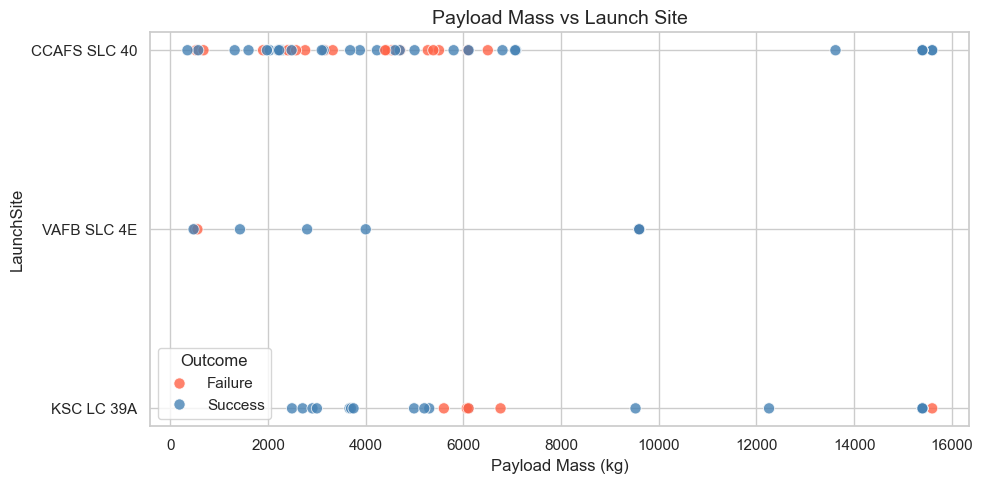

In [4]:
fig, ax = plt.subplots()
sns.scatterplot(
    data=df, x='PayloadMass', y='LaunchSite',
    hue='Class', palette={0: 'tomato', 1: 'steelblue'},
    s=65, alpha=0.8, ax=ax
)
ax.set_title("Payload Mass vs Launch Site")
ax.set_xlabel("Payload Mass (kg)")
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ['Failure', 'Success'], title="Outcome")
plt.tight_layout()
plt.show()


### 3 — Success rate per orbit type

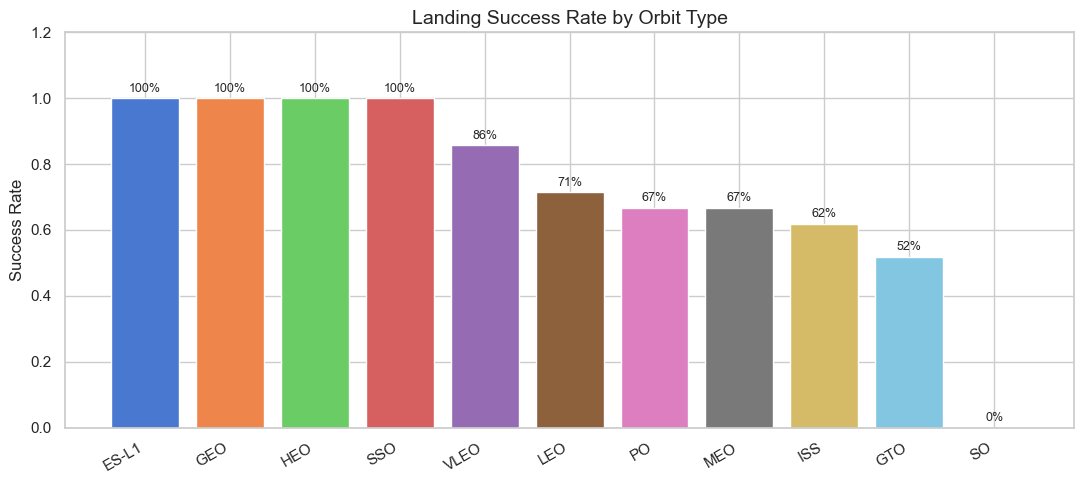

In [5]:
orbit_success = (
    df.groupby('Orbit')['Class']
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)
orbit_success.columns = ['Orbit', 'SuccessRate']

fig, ax = plt.subplots(figsize=(11, 5))
colors = sns.color_palette("muted", len(orbit_success))
bars = ax.bar(orbit_success['Orbit'], orbit_success['SuccessRate'], color=colors)
for bar, rate in zip(bars, orbit_success['SuccessRate']):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
        f"{rate:.0%}", ha='center', fontsize=9
    )
ax.set_title("Landing Success Rate by Orbit Type")
ax.set_ylabel("Success Rate")
ax.set_ylim(0, 1.2)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


### 4 — Success rate over time (flight number trend)

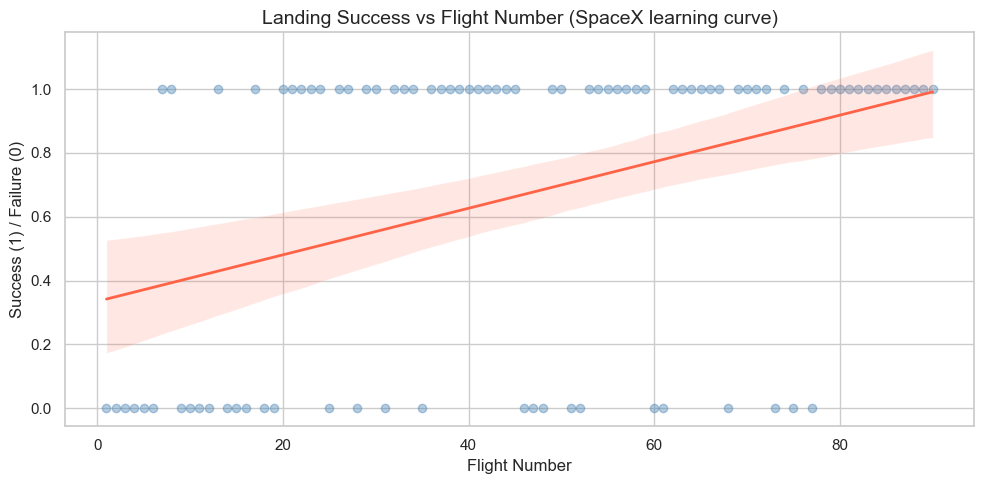

In [6]:
fig, ax = plt.subplots()
sns.regplot(
    data=df, x='FlightNumber', y='Class',
    scatter_kws={'alpha': 0.4, 'color': 'steelblue'},
    line_kws={'color': 'tomato', 'linewidth': 2},
    ax=ax
)
ax.set_title("Landing Success vs Flight Number (SpaceX learning curve)")
ax.set_ylabel("Success (1) / Failure (0)")
ax.set_xlabel("Flight Number")
plt.tight_layout()
plt.show()


### 5 — Payload mass vs landing success

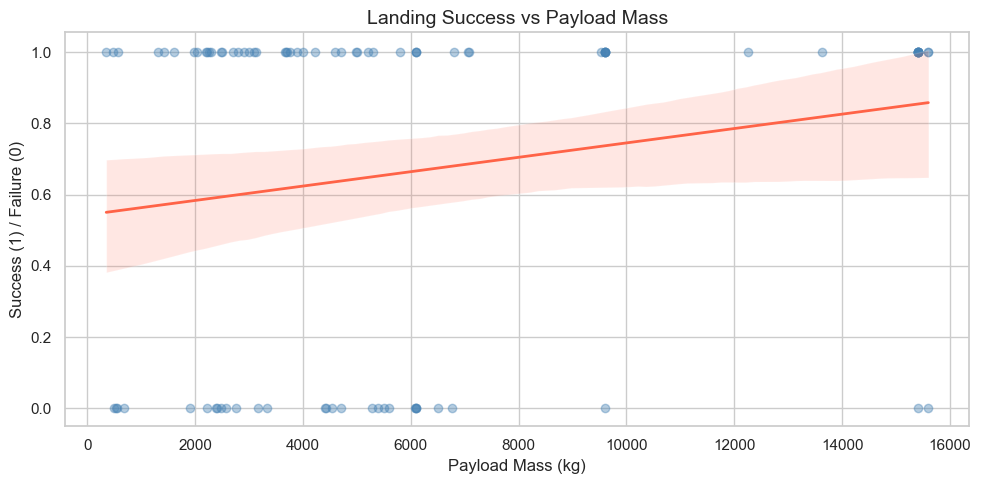

In [7]:
fig, ax = plt.subplots()
sns.regplot(
    data=df, x='PayloadMass', y='Class',
    scatter_kws={'alpha': 0.4, 'color': 'steelblue'},
    line_kws={'color': 'tomato', 'linewidth': 2},
    ax=ax
)
ax.set_title("Landing Success vs Payload Mass")
ax.set_ylabel("Success (1) / Failure (0)")
ax.set_xlabel("Payload Mass (kg)")
plt.tight_layout()
plt.show()


### 6 — Success count per launch site (bar chart)

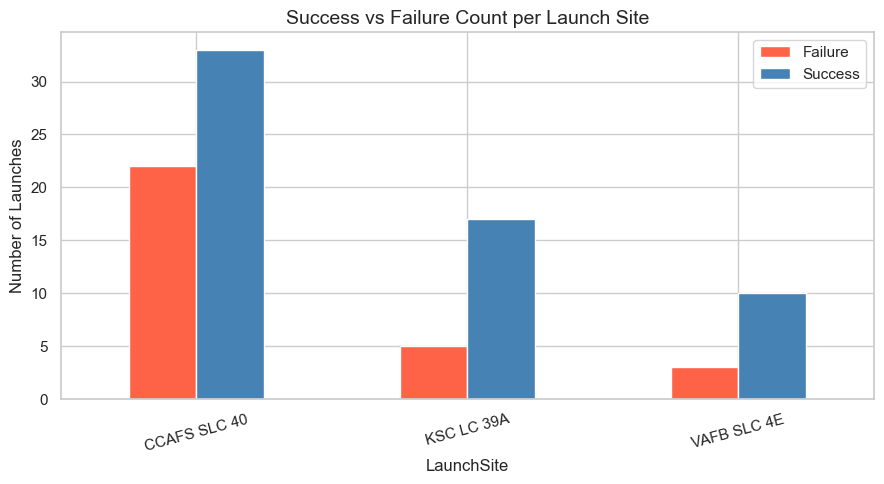

In [8]:
site_counts = df.groupby(['LaunchSite', 'Class']).size().unstack(fill_value=0)
site_counts.columns = ['Failure', 'Success']
site_counts.plot(kind='bar', color=['tomato', 'steelblue'], figsize=(9, 5))
plt.title("Success vs Failure Count per Launch Site")
plt.ylabel("Number of Launches")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


### 7 — One-hot encode categoricals for ML

In [9]:
features = [
    'FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite',
    'Flights', 'GridFins', 'Reused', 'Legs',
    'LandingPad', 'Block', 'ReusedCount', 'Serial'
]

X = pd.get_dummies(df[features])
Y = df['Class']

print(f"Feature matrix : {X.shape}")
print(f"Label counts   : {Y.value_counts().to_dict()}")


Feature matrix : (90, 80)
Label counts   : {1: 60, 0: 30}


In [10]:
X.to_csv("../data/spacex_features.csv", index=False)
Y.to_csv("../data/spacex_labels.csv", index=False)
print("Feature matrix and labels saved.")


Feature matrix and labels saved.
